<a href="https://colab.research.google.com/github/ghizlane89/0__GenIA/blob/Bootcamp/W5_D5_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Étape 1 – Preprocess the Data

In [2]:
import os
import zipfile
import tensorflow as tf

# URL du dataset
url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"

# Télécharger (sans extraction automatique)
path_to_zip = tf.keras.utils.get_file("cats_and_dogs_filtered.zip", origin=url, extract=False)

# Définir le chemin d’extraction
extract_path = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

# Extraire manuellement si ce n’est pas déjà fait
if not os.path.exists(extract_path):
    with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
        zip_ref.extractall(os.path.dirname(path_to_zip))

# Définir les chemins vers les répertoires d'entraînement et de validation
train_dir = os.path.join(extract_path, 'train')
validation_dir = os.path.join(extract_path, 'validation')


from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paramètres
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Générateur avec rescale uniquement (comme demandé)
train_image_generator = ImageDataGenerator(rescale=1./255)
validation_image_generator = ImageDataGenerator(rescale=1./255)

# Générateur d'entraînement
train_data_gen = train_image_generator.flow_from_directory(
    batch_size=BATCH_SIZE,
    directory=train_dir,
    shuffle=True,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

# Générateur de validation
val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=BATCH_SIZE,
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)



68606236/68606236 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


## Etape 2: Build the Model

In [3]:
from tensorflow.keras import layers, models

# Définir le modèle CNN
model = models.Sequential([
    # 1ère couche convolutionnelle
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # 2ème couche convolutionnelle
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # 3ème couche convolutionnelle
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Dropout pour régularisation
    layers.Dropout(0.5),

    # Passage au dense
    layers.Flatten(),
    layers.Dense(512, activation='relu'),

    # Couche de sortie binaire
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

## Etape 3: Train the Model:

In [5]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
EPOCHS = 15


history = model.fit(
    train_data_gen,
    steps_per_epoch=train_data_gen.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=val_data_gen.samples // BATCH_SIZE,
    verbose=2
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/62 - 15s - 245ms/step - accuracy: 0.5163 - loss: 0.7139 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 2/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

62/62 - 1s - 23ms/step - accuracy: 0.5938 - loss: 0.7062 - val_accuracy: 0.6845 - val_loss: 0.5940
Epoch 11/15
62/62 - 4s - 71ms/step - accuracy: 0.7785 - loss: 0.4581 - val_accuracy: 0.7067 - val_loss: 0.5749
Epoch 12/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 - 1s - 23ms/step - accuracy: 0.6875 - loss: 0.4854 - val_accuracy: 0.7077 - val_loss: 0.5694
Epoch 13/15
62/62 - 5s - 81ms/step - accuracy: 0.8379 - loss: 0.3628 - val_accuracy: 0.7167 - val_loss: 0.6053
Epoch 14/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 - 1s - 23ms/step - accuracy: 0.7812 - loss: 0.4169 - val_accuracy: 0.7137 - val_loss: 0.6053
Epoch 15/15
62/62 - 9s - 143ms/step - accuracy: 0.8750 - loss: 0.2820 - val_accuracy: 0.7087 - val_loss: 0.6345


## Etape 4: Evaluate The Model

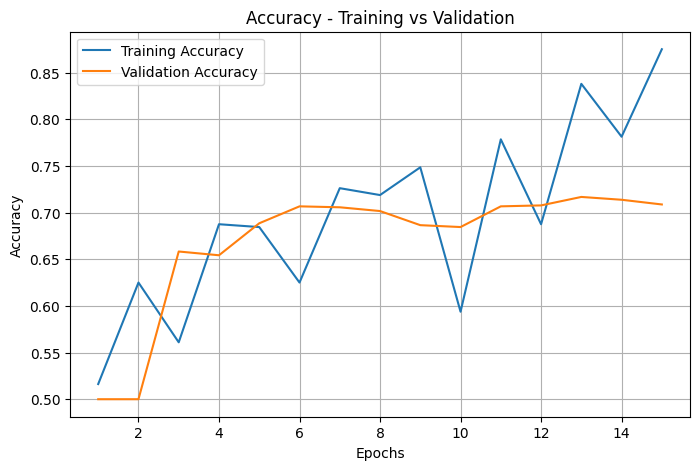

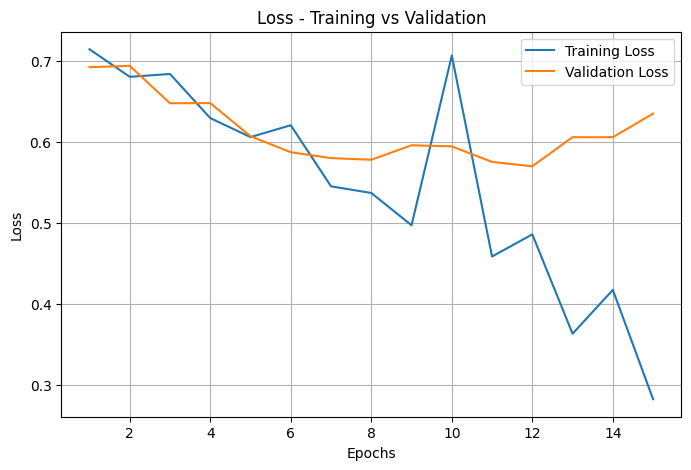

In [6]:
import matplotlib.pyplot as plt

# Récupérer les métriques du modèle
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Courbe de précision
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy - Training vs Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Courbe de perte
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss - Training vs Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Évaluation du modèle CNN
Accuracy (Précision) :
La précision d'entraînement monte jusqu’à environ 88 %.

La précision de validation stagne autour de 70–72 % dès la 6e époque.

Le modèle apprend bien sur les données d'entraînement.

Overfitting visible à partir de l’époque 7–8.

Loss (Erreur) :
L’erreur d'entraînement diminue fortement (ce qui est positif).

L’erreur de validation baisse jusqu’à l’époque 8 puis remonte ensuite, ce qui montre un surapprentissage.

Conclusion :
Le modèle apprend bien, mais généralise mal au-delà de 8 époques.

Le dropout et la data augmentation améliorent un peu la généralisation, mais ne suffisent pas à éviter totalement l’overfitting.

Au-delà d’un certain point, continuer l’entraînement dégrade la performance sur les données de validation.

